In [1]:
!pip install -q piq scikit-image opencv-python-headless timm albumentations

import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Count:       {torch.cuda.device_count()}")
    print(f"GPU Device 0:    {torch.cuda.get_device_name(0)}")

^C


KeyboardInterrupt: 

In [ ]:
import os
import gc
import cv2
import time
import glob
import math
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import piq
from skimage.metrics import structural_similarity as compute_skimage_ssim

warnings.filterwarnings('ignore')

class Config:
    SEED = 42
    NUM_GPUS = torch.cuda.device_count()
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = os.cpu_count() or 4

    # Auto-detect dataset directory across various Kaggle and local paths
    CANDIDATES = [
        '/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
        '/kaggle/input/covid-19-radiography-database/COVID-19_Radiography_Dataset',
        '/kaggle/input/covid19-radiography-database',
        '/kaggle/input/covid-19-radiography-database',
        '/kaggle/input',
        './data/dataset1_covid_radiography',
        '.'
    ]

    INPUT_DATASET_DIR = None
    for cand in CANDIDATES:
        if os.path.exists(cand):
            # Check if there are image files inside
            for root, _, files in os.walk(cand):
                if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) and 'mask' not in f.lower() for f in files):
                    INPUT_DATASET_DIR = cand
                    break
            if INPUT_DATASET_DIR:
                break

    if INPUT_DATASET_DIR is None:
        INPUT_DATASET_DIR = '/kaggle/input'

    WORKING_DIR = '/kaggle/working/qaap_pipeline'
    OUTPUT_PREPROCESSED_DIR = os.path.join(WORKING_DIR, 'qaap_processed_images')
    LOGS_DIR = os.path.join(WORKING_DIR, 'logs')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

    TARGET_SIZE = (224, 224)
    BATCH_SIZE_IQA = 256 if NUM_GPUS > 1 else 128

    BIN_LABELS = ['Very Poor', 'Poor', 'Medium', 'Good', 'Excellent']
    NUM_BINS = 5

for d in [Config.WORKING_DIR, Config.OUTPUT_PREPROCESSED_DIR, Config.LOGS_DIR, Config.METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"[INIT] Device: {Config.DEVICE} ({Config.NUM_GPUS} GPUs) | CPU Workers: {Config.NUM_WORKERS}")
print(f"[INIT] Detected Dataset Path: {Config.INPUT_DATASET_DIR}")
if os.path.exists('/kaggle/input'):
    print(f"[INIT] Available in /kaggle/input: {os.listdir('/kaggle/input')}")

In [ ]:
def discover_cxr_images(dataset_root):
    valid_exts = {'.png', '.jpg', '.jpeg'}
    image_records = []

    print(f"[SCAN] Searching for CXR images in: {dataset_root}")
    for root, _, files in os.walk(dataset_root):
        # Exclude mask folders
        if 'mask' in root.lower():
            continue
        for f in files:
            # Exclude mask files
            if 'mask' in f.lower():
                continue
            ext = os.path.splitext(f)[1].lower()
            if ext in valid_exts:
                full_path = os.path.join(root, f)
                parent_dir = os.path.basename(root)
                grandparent_dir = os.path.basename(os.path.dirname(root))

                # Determine class label (COVID, Normal, Lung_Opacity, Viral Pneumonia, etc.)
                if parent_dir.lower() in ['images', 'imgs']:
                    class_label = grandparent_dir
                else:
                    class_label = parent_dir

                image_records.append({
                    'file_path': full_path,
                    'file_name': f,
                    'class': class_label
                })

    # Explicit column initialization prevents KeyError even if image_records is empty
    df = pd.DataFrame(image_records, columns=['file_path', 'file_name', 'class'])

    if len(df) == 0:
        print(f"[ERROR] No images found under '{dataset_root}'!")
        print(f"[DIAGNOSTIC] Listing contents of /kaggle/input:")
        if os.path.exists('/kaggle/input'):
            for item in os.listdir('/kaggle/input'):
                print(f"  - /kaggle/input/{item}")
        print("\nPlease ensure you added the dataset via '+ Add Data' in Kaggle.")
        return df

    print(f"[DATASET] Discovered {len(df)} CXR images across classes: {df['class'].unique().tolist()}")
    return df


class CXRQualityDataset(Dataset):
    def __init__(self, file_paths, target_size=(224, 224)):
        self.file_paths = file_paths
        self.target_size = target_size

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros(self.target_size, dtype=np.uint8)
        else:
            if img.shape[:2] != self.target_size:
                img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        tensor_img = torch.from_numpy(img).float().unsqueeze(0) / 255.0
        return tensor_img, path


class CXRQualityEvaluator:
    def __init__(self, device=Config.DEVICE, batch_size=Config.BATCH_SIZE_IQA):
        self.device = device
        self.batch_size = batch_size
        self.bin_edges = None
        self.bin_labels = Config.BIN_LABELS

    def compute_dataset_quality(self, file_paths):
        dataset = CXRQualityDataset(file_paths, target_size=Config.TARGET_SIZE)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=Config.NUM_WORKERS,
            pin_memory=True if self.device.type == 'cuda' else False,
            drop_last=False
        )

        all_paths, raw_brisque_scores = [], []
        start_time = time.time()

        with torch.no_grad():
            for batch_imgs, batch_paths in tqdm(loader, desc="GPU BRISQUE Extraction"):
                batch_imgs = batch_imgs.to(self.device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                    try:
                        scores = piq.brisque(batch_imgs, reduction='none', data_range=1.0)
                        scores_list = scores.detach().cpu().numpy().flatten().tolist()
                    except Exception:
                        scores_list = [50.0] * batch_imgs.size(0)

                raw_brisque_scores.extend(scores_list)
                all_paths.extend(batch_paths)

        elapsed = time.time() - start_time
        print(f"[IQA] Completed in {elapsed:.2f}s ({len(file_paths)/max(elapsed, 1e-3):.1f} img/sec)")

        raw_scores_arr = np.nan_to_num(np.array(raw_brisque_scores, dtype=np.float32), nan=50.0)
        quality_indices = np.clip(100.0 - raw_scores_arr, 0.0, 100.0)

        return pd.DataFrame({
            'file_path': all_paths,
            'raw_brisque': raw_scores_arr,
            'quality_score': quality_indices
        })

    def fit_and_assign_bins(self, df_scores):
        quantiles = [0.20, 0.40, 0.60, 0.80]
        self.bin_edges = np.quantile(df_scores['quality_score'], quantiles).tolist()

        print("\n[BINNING] Empirical Quantile Cutoffs:")
        print(f"  Tier 0 (Very Poor) : [  0.00 -> {self.bin_edges[0]:.2f} ]")
        print(f"  Tier 1 (Poor)      : [ {self.bin_edges[0]:.2f} -> {self.bin_edges[1]:.2f} ]")
        print(f"  Tier 2 (Medium)    : [ {self.bin_edges[1]:.2f} -> {self.bin_edges[2]:.2f} ]")
        print(f"  Tier 3 (Good)      : [ {self.bin_edges[2]:.2f} -> {self.bin_edges[3]:.2f} ]")
        print(f"  Tier 4 (Excellent) : [ {self.bin_edges[3]:.2f} -> 100.00 ]")

        def _map_bin(score):
            if score <= self.bin_edges[0]: return 0, self.bin_labels[0]
            elif score <= self.bin_edges[1]: return 1, self.bin_labels[1]
            elif score <= self.bin_edges[2]: return 2, self.bin_labels[2]
            elif score <= self.bin_edges[3]: return 3, self.bin_labels[3]
            else: return 4, self.bin_labels[4]

        res = df_scores['quality_score'].apply(_map_bin)
        df_scores['bin_id'] = [r[0] for r in res]
        df_scores['bin_label'] = [r[1] for r in res]
        return df_scores

In [ ]:
class AdaptiveImageProcessor:
    @staticmethod
    def apply_pipeline(img_gray, clip_limit=2.0, denoise_h=4, sharpen=False):
        if img_gray.dtype != np.uint8:
            img_gray = np.clip(img_gray, 0, 255).astype(np.uint8)

        # 1. Contrast Equalization (CLAHE)
        if clip_limit > 0.0:
            clahe = cv2.createCLAHE(clipLimit=float(clip_limit), tileGridSize=(8, 8))
            enhanced = clahe.apply(img_gray)
        else:
            enhanced = img_gray

        # 2. Optimized NLM Noise Filtering
        if denoise_h > 0:
            denoised = cv2.fastNlMeansDenoising(
                enhanced, None, h=int(denoise_h), templateWindowSize=5, searchWindowSize=13
            )
        else:
            denoised = enhanced

        # 3. Structural Margin Sharpening
        if sharpen:
            blurred = cv2.GaussianBlur(denoised, (0, 0), sigmaX=1.5)
            sharpened = cv2.addWeighted(denoised, 1.4, blurred, -0.4, 0)
            return np.clip(sharpened, 0, 255).astype(np.uint8)

        return denoised


class QAAPOptimizer:
    def __init__(self):
        self.search_space = {
            'clip_limit': [1.0, 2.0, 3.0, 4.0],
            'denoise_h': [0, 4, 8, 12, 16],
            'sharpen': [False, True]
        }
        self.param_combinations = [
            {'clip_limit': c, 'denoise_h': d, 'sharpen': s}
            for c in self.search_space['clip_limit']
            for d in self.search_space['denoise_h']
            for s in self.search_space['sharpen']
        ]

    @staticmethod
    def _apply_synthetic_degradation(img, tier):
        degraded = img.astype(np.float32)
        # Contrast degradation
        contrast_factor = 0.5 + 0.1 * tier
        degraded = np.clip((degraded - 128.0) * contrast_factor + 128.0, 0, 255)
        # Quantum mottle noise
        noise_sigma = max(0.0, (4 - tier) * 6.0)
        if noise_sigma > 0:
            degraded = np.clip(degraded + np.random.normal(0, noise_sigma, degraded.shape), 0, 255)
        # Motion blur
        if tier <= 1:
            ksize = 5 if tier == 0 else 3
            degraded = cv2.GaussianBlur(degraded, (ksize, ksize), 0)
        return degraded.astype(np.uint8)

    def optimize_lookup_table(self, reference_paths):
        print("\n=======================================================")
        print(" OPTIMIZING PREPROCESSING PARAMETERS (SDR-SSIM)")
        print("=======================================================")

        ref_imgs = []
        for p in reference_paths[:30]:
            im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if im is not None:
                ref_imgs.append(cv2.resize(im, Config.TARGET_SIZE))

        lookup_table = {}
        summary_records = []

        for tier in range(Config.NUM_BINS):
            bin_label = Config.BIN_LABELS[tier]
            best_score = -1.0
            best_params = self.param_combinations[0]

            val_pairs = [(ref, self._apply_synthetic_degradation(ref, tier)) for ref in ref_imgs]

            for params in self.param_combinations:
                ssim_list = []
                for clean_ref, degraded_in in val_pairs:
                    restored = AdaptiveImageProcessor.apply_pipeline(
                        degraded_in,
                        clip_limit=params['clip_limit'],
                        denoise_h=params['denoise_h'],
                        sharpen=params['sharpen']
                    )
                    score = compute_skimage_ssim(
                        restored, clean_ref, data_range=255, gaussian_weights=True, sigma=1.5
                    )
                    ssim_list.append(score)

                mean_ssim = float(np.mean(ssim_list))
                if mean_ssim > best_score:
                    best_score = mean_ssim
                    best_params = params

            lookup_table[tier] = {
                'bin_label': bin_label,
                'clip_limit': best_params['clip_limit'],
                'denoise_h': best_params['denoise_h'],
                'sharpen': best_params['sharpen'],
                'restoration_ssim': best_score
            }

            summary_records.append({
                'bin_id': tier,
                'bin_label': bin_label,
                'clip_limit': best_params['clip_limit'],
                'denoise_h': best_params['denoise_h'],
                'sharpen': best_params['sharpen'],
                'restoration_ssim': best_score
            })

            print(f"[OPTIMIZED] Tier {tier} ({bin_label:<9}): CLAHE={best_params['clip_limit']}, "
                  f"NLM_h={best_params['denoise_h']:<2}, Sharpen={str(best_params['sharpen']):<5} "
                  f"| SDR-SSIM: {best_score:.4f}")

        df_lut = pd.DataFrame(summary_records)
        df_lut.to_csv(os.path.join(Config.METRICS_DIR, 'qaap_optimal_lookup_table.csv'), index=False)
        return lookup_table, df_lut

In [ ]:
def _worker_process_image(item):
    cv2.setNumThreads(0)
    in_p, out_p, clip_limit, denoise_h, sharpen = item
    try:
        img = cv2.imread(in_p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False

        resized = cv2.resize(img, Config.TARGET_SIZE, interpolation=cv2.INTER_AREA)
        processed = AdaptiveImageProcessor.apply_pipeline(
            resized, clip_limit=clip_limit, denoise_h=denoise_h, sharpen=sharpen
        )
        rgb_out = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)

        os.makedirs(os.path.dirname(out_p), exist_ok=True)
        cv2.imwrite(out_p, rgb_out)
        return True
    except Exception:
        return False


def execute_qaap_dataset_generation(df_annotated, lookup_table, output_root):
    print(f"\n[PIPELINE] Processing {len(df_annotated)} images to '{output_root}'...")

    tasks = []
    for _, row in df_annotated.iterrows():
        tier_params = lookup_table[row['bin_id']]
        out_path = os.path.join(output_root, row['class'], row['file_name'])
        tasks.append((
            row['file_path'],
            out_path,
            tier_params['clip_limit'],
            tier_params['denoise_h'],
            tier_params['sharpen']
        ))

    start_time = time.time()
    success = 0
    with ProcessPoolExecutor(max_workers=Config.NUM_WORKERS) as executor:
        for res in tqdm(executor.map(_worker_process_image, tasks, chunksize=64), total=len(tasks), desc="QAAP Generation"):
            if res:
                success += 1

    elapsed = time.time() - start_time
    print(f"[PIPELINE] Completed in {elapsed:.2f}s ({success}/{len(tasks)} images written | {len(tasks)/max(elapsed, 1e-3):.1f} img/sec)")

In [ ]:
def generate_audit_visualizations(df_scores, lookup_table):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Histogram
    sns.histplot(df_scores['quality_score'], kde=True, ax=axes[0], color='#2b5c8f', bins=40)
    axes[0].set_title('Inverted BRISQUE Score Distribution ($Q \in [0, 100]$)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Quality Index $Q(I)$', fontsize=10)
    axes[0].set_ylabel('CXR Image Count', fontsize=10)

    # 2. Boxplot
    sns.boxplot(data=df_scores, x='class', y='quality_score', ax=axes[1], palette='Blues_r')
    axes[1].set_title('Quality Score Variance Across Pathology Classes', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class Label', fontsize=10)
    axes[1].set_ylabel('Quality Index $Q(I)$', fontsize=10)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.METRICS_DIR, 'qaap_quality_audit.png'), dpi=300)
    plt.show()

In [ ]:
def main():
    print("==================================================================")
    print(" STARTING QAAP PIPELINE EXECUTION (PHASE 2)")
    print("==================================================================")

    # 1. Discover data
    df_raw = discover_cxr_images(Config.INPUT_DATASET_DIR)
    if len(df_raw) == 0:
        return

    # 2. Compute GPU BRISQUE Scores
    evaluator = CXRQualityEvaluator(device=Config.DEVICE, batch_size=Config.BATCH_SIZE_IQA)
    df_scores = evaluator.compute_dataset_quality(df_raw['file_path'].tolist())
    df_full = df_raw.merge(df_scores, on='file_path')

    # 3. Bin into 5 Quantile Tiers
    df_annotated = evaluator.fit_and_assign_bins(df_full)
    df_annotated.to_csv(os.path.join(Config.METRICS_DIR, 'cxr_quality_scores.csv'), index=False)

    # 4. Parameter Grid Search Optimization
    top_references = df_annotated.sort_values(by='quality_score', ascending=False)['file_path'].head(100).tolist()
    optimizer = QAAPOptimizer()
    lookup_table, df_lut = optimizer.optimize_lookup_table(top_references)

    # 5. Apply QAAP Across Full Dataset
    execute_qaap_dataset_generation(df_annotated, lookup_table, Config.OUTPUT_PREPROCESSED_DIR)

    # 6. Generate Diagnostic Visualizations
    generate_audit_visualizations(df_annotated, lookup_table)
    print("\n[SUCCESS] Phase 2 Execution Complete!")

main()

In [ ]:
import os
import cv2
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class Phase3Config:
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = os.cpu_count() or 4
    BATCH_SIZE = 32
    NUM_EPOCHS = 8
    LEARNING_RATE = 1e-3
    TARGET_SIZE = (224, 224)
    MARGIN_PAD_RATIO = 0.05  # 5% anatomical context padding around lungs

    # Input candidates (Auto-detects from local Phase 2 run or attached dataset)
    QAAP_CANDIDATES = [
        '/kaggle/working/qaap_pipeline/qaap_processed_images',
        '/kaggle/input/qaap-preprocessed-cxr/qaap_processed_images',
        '/kaggle/input/qaap-preprocessed-cxr'
    ]
    QAAP_INPUT_DIR = next((p for p in QAAP_CANDIDATES if os.path.exists(p)), QAAP_CANDIDATES[0])

    # Output directories
    WORKING_DIR = '/kaggle/working/phase3_segmentation'
    OUTPUT_SEGMENTED_DIR = os.path.join(WORKING_DIR, 'segmented_lung_images')
    MODELS_DIR = os.path.join(WORKING_DIR, 'models')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

for d in [Phase3Config.WORKING_DIR, Phase3Config.OUTPUT_SEGMENTED_DIR,
          Phase3Config.MODELS_DIR, Phase3Config.METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"[PHASE 3 INIT] Device: {Phase3Config.DEVICE} | QAAP Source: {Phase3Config.QAAP_INPUT_DIR}")

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder (Downsampling)
        curr_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(curr_in, feature))
            curr_in = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder (Upsampling)
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        # Final Classifier (Returns raw logits for numerical stability with AMP)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)  # Returns logits


class DiceBCEWithLogitsLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        # Sigmoid for dice computation
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice_loss = 1.0 - ((2.0 * intersection + self.smooth) /
                           (probs_flat.sum() + targets_flat.sum() + self.smooth))

        return 0.5 * bce_loss + 0.5 * dice_loss

In [ ]:
# Cell 10: Mask Discovery & Dataset Builder
def discover_mask_pairs(raw_root, qaap_root):
    """
    Pairs QAAP preprocessed images with ground-truth masks from the raw dataset.
    """
    qaap_imgs = glob.glob(os.path.join(qaap_root, '**', '*.png'), recursive=True)
    if not qaap_imgs:
        qaap_imgs = glob.glob(os.path.join(qaap_root, '**', '*.jpg'), recursive=True)

    print(f"[PAIRING] Discovered {len(qaap_imgs)} QAAP processed images.")

    # Build fast mask lookup table
    raw_masks = {}
    for root, _, files in os.walk(raw_root):
        if 'mask' in root.lower():
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    raw_masks[f.lower()] = os.path.join(root, f)

    paired_records = []
    for q_path in qaap_imgs:
        f_name = os.path.basename(q_path).lower()
        # In COVID-19 dataset, mask matches image filename or has 'mask' in name
        mask_path = raw_masks.get(f_name, None)

        paired_records.append({
            'qaap_path': q_path,
            'mask_path': mask_path,
            'class': os.path.basename(os.path.dirname(q_path)),
            'file_name': os.path.basename(q_path)
        })

    df = pd.DataFrame(paired_records)
    has_mask_count = df['mask_path'].notnull().sum()
    print(f"[PAIRING] {has_mask_count}/{len(df)} images successfully paired with ground-truth masks.")
    return df


class SegmentationDataset(Dataset):
    def __init__(self, df, target_size=Phase3Config.TARGET_SIZE, is_train=True):
        self.df = df.reset_index(drop=True)
        self.target_size = target_size
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load QAAP Image (3 channels)
        img = cv2.imread(row['qaap_path'], cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((*self.target_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if img.shape[:2] != self.target_size:
                img = cv2.resize(img, self.target_size)

        # Load Mask (1 channel)
        if pd.notnull(row['mask_path']) and os.path.exists(row['mask_path']):
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros(self.target_size, dtype=np.uint8)
            else:
                if mask.shape[:2] != self.target_size:
                    mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        else:
            mask = np.zeros(self.target_size, dtype=np.uint8)

        # Normalization
        img_tensor = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        mask_tensor = (torch.from_numpy(mask).float().unsqueeze(0) > 127).float()

        return img_tensor, mask_tensor

In [ ]:
# Cell 11: U-Net Training Loop with Mixed Precision
def train_unet_segmentor(df_train, df_val):
    train_ds = SegmentationDataset(df_train, is_train=True)
    val_ds = SegmentationDataset(df_val, is_train=False)

    train_loader = DataLoader(
        train_ds, batch_size=Phase3Config.BATCH_SIZE, shuffle=True,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=Phase3Config.BATCH_SIZE, shuffle=False,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )

    model = UNet(in_channels=3, out_channels=1).to(Phase3Config.DEVICE)
    criterion = DiceBCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=Phase3Config.LEARNING_RATE, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    best_val_dice = 0.0
    best_model_path = os.path.join(Phase3Config.MODELS_DIR, 'unet_lung_best.pth')

    print("\n=======================================================")
    print(" TRAINING U-NET LUNG FIELD SEGMENTATION MODEL")
    print("=======================================================")

    for epoch in range(Phase3Config.NUM_EPOCHS):
        model.train()
        train_loss, train_dice = 0.0, 0.0

        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Phase3Config.NUM_EPOCHS} [Train]"):
            imgs = imgs.to(Phase3Config.DEVICE, non_blocking=True)
            masks = masks.to(Phase3Config.DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * imgs.size(0)

            # Binary Dice metric calculation
            preds_bin = (torch.sigmoid(logits) > 0.5).float()
            dice = (2.0 * (preds_bin * masks).sum()) / (preds_bin.sum() + masks.sum() + 1e-7)
            train_dice += dice.item() * imgs.size(0)

        train_loss /= len(train_ds)
        train_dice /= len(train_ds)

        # Validation
        model.eval()
        val_loss, val_dice = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(Phase3Config.DEVICE, non_blocking=True)
                masks = masks.to(Phase3Config.DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)

                val_loss += loss.item() * imgs.size(0)
                preds_bin = (torch.sigmoid(logits) > 0.5).float()
                dice = (2.0 * (preds_bin * masks).sum()) / (preds_bin.sum() + masks.sum() + 1e-7)
                val_dice += dice.item() * imgs.size(0)

        val_loss /= len(val_ds)
        val_dice /= len(val_ds)

        print(f"Epoch [{epoch+1:02d}/{Phase3Config.NUM_EPOCHS:02d}] "
              f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), best_model_path)
            print(f"  --> Saved Best U-Net Model (Val Dice: {val_dice:.4f})")

    print(f"\n[MODEL] Best U-Net Validation Dice: {best_val_dice:.4f}")
    return best_model_path

In [ ]:
# Cell 12: High-Speed Batch Segmentation & ROI Cropping
def crop_lung_roi(img_rgb, binary_mask, pad_ratio=0.05):
    """
    Extracts the bounding box enclosing both lungs with padding and resizes to 224x224.
    """
    h, w = binary_mask.shape
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return cv2.resize(img_rgb, Phase3Config.TARGET_SIZE)

    # Filter out tiny spurious noisy contours
    min_area = 0.01 * (h * w)
    valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

    if not valid_contours:
        valid_contours = contours

    all_points = np.vstack(valid_contours)
    x, y, bw, bh = cv2.boundingRect(all_points)

    # Contextual padding
    pad_x = int(bw * pad_ratio)
    pad_y = int(bh * pad_ratio)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    cropped = img_rgb[y1:y2, x1:x2]
    return cv2.resize(cropped, Phase3Config.TARGET_SIZE, interpolation=cv2.INTER_AREA)


def generate_segmented_dataset(df_all, model_path):
    print(f"\n[INFERENCE] Segmenting and ROI cropping {len(df_all)} images...")

    model = UNet(in_channels=3, out_channels=1).to(Phase3Config.DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=Phase3Config.DEVICE))
    model.eval()

    dataset = SegmentationDataset(df_all, is_train=False)
    loader = DataLoader(
        dataset, batch_size=Phase3Config.BATCH_SIZE * 2, shuffle=False,
        num_workers=Phase3Config.NUM_WORKERS, pin_memory=True
    )

    all_indices = 0
    start_time = time.time()
    sample_visuals = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="U-Net Segmentation & ROI Crop"):
            imgs_cuda = imgs.to(Phase3Config.DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                logits = model(imgs_cuda)
                pred_masks = torch.sigmoid(logits)

            pred_masks_np = (pred_masks.cpu().numpy() > 0.5).astype(np.uint8)[:, 0, :, :]
            imgs_np = (imgs.permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)

            for i in range(len(imgs_np)):
                row = df_all.iloc[all_indices]
                out_path = os.path.join(
                    Phase3Config.OUTPUT_SEGMENTED_DIR, row['class'], row['file_name']
                )
                os.makedirs(os.path.dirname(out_path), exist_ok=True)

                raw_rgb = imgs_np[i]
                mask = pred_masks_np[i] * 255

                # Morphological closing to clean up rib intersections
                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

                cropped_lung = crop_lung_roi(raw_rgb, cleaned_mask, pad_ratio=Phase3Config.MARGIN_PAD_RATIO)

                cv2.imwrite(out_path, cv2.cvtColor(cropped_lung, cv2.COLOR_RGB2BGR))

                if len(sample_visuals) < 5 and all_indices % (len(df_all) // 5 + 1) == 0:
                    sample_visuals.append((raw_rgb, cleaned_mask, cropped_lung, row['class']))

                all_indices += 1

    elapsed = time.time() - start_time
    rate = all_indices / max(elapsed, 1e-3)
    print(f"[INFERENCE] Segmented {all_indices} images in {elapsed:.2f}s ({rate:.1f} img/sec)")
    return sample_visuals

In [ ]:
def main_phase3():
    print("==================================================================")
    print(" STARTING LUNG FIELD SEGMENTATION PIPELINE (PHASE 3)")
    print("==================================================================")

    # 1. Discover pairs
    raw_root = Config.INPUT_DATASET_DIR
    qaap_root = Phase3Config.QAAP_INPUT_DIR
    df_all = discover_mask_pairs(raw_root, qaap_root)

    # 2. Filter images with masks for training/validation
    df_with_masks = df_all[df_all['mask_path'].notnull()].copy()

    # Train on a stratified subset (fast convergence in ~2 mins)
    df_train, df_val = train_test_split(
        df_with_masks, test_size=0.2, random_state=Phase3Config.SEED,
        stratify=df_with_masks['class']
    )
    print(f"[DATA SPLIT] Training Masks: {len(df_train)} | Validation Masks: {len(df_val)}")

    # 3. Train U-Net
    best_model_path = train_unet_segmentor(df_train, df_val)

    # 4. Generate ROI Segmented Dataset
    samples = generate_segmented_dataset(df_all, best_model_path)

    # 5. Visual Inspection Plot
    fig, axes = plt.subplots(len(samples), 3, figsize=(12, 3.5 * len(samples)))
    if len(samples) == 1:
        axes = np.expand_dims(axes, 0)

    col_titles = ["QAAP Input CXR", "U-Net Lung Mask", "Cropped ROI (Phase 4/5 Input)"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, (orig, mask, cropped, cls_name) in enumerate(samples):
        axes[i, 0].imshow(orig)
        axes[i, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(cropped)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(Phase3Config.METRICS_DIR, 'unet_segmentation_samples.png'), dpi=300)
    plt.show()

    print("\n[SUCCESS] Phase 3 Lung Segmentation Complete!")

main_phase3()

In [ ]:
# Cell 13.5: Full GPU & IPython Memory Purge
import gc
import sys
import torch

# Clear Jupyter/IPython internal output history
if 'IPython' in sys.modules:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('reset_selective', '-f ^(unet|model|ssl_model|optimizer|scaler|img_batch|mask_batch|probs|loss)')
        if hasattr(ip, 'user_ns'):
            for key in list(ip.user_ns.keys()):
                if key.startswith('_') or key in ['Out', 'In']:
                    continue

# Clear GPU cache
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Report available memory
free_vram = torch.cuda.mem_get_info()[0] / (1024**3)
total_vram = torch.cuda.mem_get_info()[1] / (1024**3)
print(f"[VRAM RECLAIMED] Free GPU Memory: {free_vram:.2f} GB / {total_vram:.2f} GB")

In [ ]:
import os
import glob
import gc
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

# Clear any lingering GPU cache
gc.collect()
torch.cuda.empty_cache()

class Phase4Config:
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 2
    BATCH_SIZE = 32           # Safe for 15GB T4 VRAM with ConvNeXt-Small
    EPOCHS = 15               # Number of SSL pretraining epochs
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 1e-4
    TEMPERATURE = 0.07        # NT-Xent temperature scaling
    EMBEDDING_DIM = 128       # Projection head output dimension
    TARGET_SIZE = (224, 224)
    BACKBONE = 'convnext_small'

    # Dataset search root
    DATA_ROOT = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'
    WORKING_DIR = '/kaggle/working/phase4_ssl'
    MODELS_DIR = os.path.join(WORKING_DIR, 'models')
    METRICS_DIR = os.path.join(WORKING_DIR, 'metrics')

# Ensure output directories exist
os.makedirs(Phase4Config.MODELS_DIR, exist_ok=True)
os.makedirs(Phase4Config.METRICS_DIR, exist_ok=True)

# Set deterministic seeds
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(Phase4Config.SEED)

# Discover all image paths across all categories
all_image_paths = sorted(glob.glob(os.path.join(Phase4Config.DATA_ROOT, '*/images/*.png')))
print(f"[Phase 4] Discovered {len(all_image_paths)} total CXR images for Self-Supervised Pretraining.")
print(f"[Phase 4] Target Device: {Phase4Config.DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

In [ ]:
class SimCLRTransform:
    """Generates two distinct stochastic augmented views (x_i, x_j) of an input image."""
    def __init__(self, size=(224, 224)):
        self.transform = T.Compose([
            T.RandomResizedCrop(size=size, scale=(0.75, 1.0), ratio=(0.85, 1.15)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)


class UnlabeledCXRDataset(Dataset):
    """Dataset for self-supervised contrastive learning (no class labels required)."""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            view1, view2 = self.transform(img)
            return view1, view2
        tensor_img = T.ToTensor()(img)
        return tensor_img, tensor_img


class SimCLRModel(nn.Module):
    """
    SimCLR Architecture:
      - Encoder Backbone: ConvNeXt-Small (feature representation h in R^D)
      - Projection Head: 2-layer MLP with BatchNorm and ReLU (projection z in R^128)
    """
    def __init__(self, backbone_name='convnext_small', projection_dim=128, pretrained=True):
        super().__init__()
        # Backbone feature extractor (num_classes=0 returns pool feature vector)
        self.encoder = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        in_features = self.encoder.num_features

        # Non-linear 2-layer MLP projection head
        self.projector = nn.Sequential(
            nn.Linear(in_features, in_features),
            nn.BatchNorm1d(in_features),
            nn.ReLU(inplace=True),
            nn.Linear(in_features, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = F.normalize(self.projector(h), dim=1)
        return h, z

# Initialize Dataset and DataLoader
ssl_dataset = UnlabeledCXRDataset(all_image_paths, transform=SimCLRTransform(Phase4Config.TARGET_SIZE))
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=Phase4Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Phase4Config.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

print(f"[Phase 4] Initialized DataLoader with {len(ssl_dataset)} samples ({len(ssl_loader)} batches per epoch).")

In [ ]:
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent).
    AMP float16 safe: similarity computation and masking are handled in float32.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        # Force float32 to prevent float16 underflow/overflow during dot product and softmax
        z_i = z_i.float()
        z_j = z_j.float()
        batch_size = z_i.size(0)

        # 2N x D representation matrix
        z = torch.cat([z_i, z_j], dim=0)

        # Cosine similarity matrix scaled by temperature: (2N, 2N)
        sim_matrix = torch.matmul(z, z.T) / self.temperature

        # Mask out self-similarities along the diagonal with safe -1e4
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim_matrix = sim_matrix.masked_fill(mask, -1e4)

        # Ground truth indices: (view1_i <-> view2_i)
        targets = (torch.arange(2 * batch_size, device=z.device) + batch_size) % (2 * batch_size)

        loss = F.cross_entropy(sim_matrix, targets)
        return loss

print("[Phase 4] NTXentLoss initialized successfully.")

In [ ]:
import time
from tqdm.notebook import tqdm

# Initialize model, optimizer, scheduler, and AMP gradient scaler
ssl_model = SimCLRModel(
    backbone_name=Phase4Config.BACKBONE,
    projection_dim=Phase4Config.EMBEDDING_DIM,
    pretrained=True
).to(Phase4Config.DEVICE)

criterion = NTXentLoss(temperature=Phase4Config.TEMPERATURE)
optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=Phase4Config.LEARNING_RATE,
    weight_decay=Phase4Config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=Phase4Config.EPOCHS,
    eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler()

best_loss = float('inf')
training_history = []

print(f"=== Starting SimCLR Pretraining on {len(all_image_paths)} Unlabeled CXRs ===")
print(f"Backbone: {Phase4Config.BACKBONE} | Epochs: {Phase4Config.EPOCHS} | Batch Size: {Phase4Config.BATCH_SIZE}")

for epoch in range(1, Phase4Config.EPOCHS + 1):
    ssl_model.train()
    total_loss = 0.0
    start_time = time.time()

    progress_bar = tqdm(ssl_loader, desc=f"Epoch [{epoch:02d}/{Phase4Config.EPOCHS:02d}]", leave=True)

    for step, (view1, view2) in enumerate(progress_bar):
        view1 = view1.to(Phase4Config.DEVICE, non_blocking=True)
        view2 = view2.to(Phase4Config.DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed-precision forward pass
        with torch.cuda.amp.autocast():
            _, z_i = ssl_model(view1)
            _, z_j = ssl_model(view2)
            loss = criterion(z_i, z_j)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = loss.item()
        total_loss += batch_loss
        progress_bar.set_postfix({'loss': f"{batch_loss:.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.2e}"})

    epoch_loss = total_loss / len(ssl_loader)
    scheduler.step()
    elapsed = time.time() - start_time

    training_history.append({'epoch': epoch, 'loss': epoch_loss, 'lr': scheduler.get_last_lr()[0], 'time': elapsed})
    print(f"Epoch {epoch:02d}/{Phase4Config.EPOCHS:02d} Complete | Avg Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s")

    # Save best and latest checkpoints
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': ssl_model.state_dict(),
        'encoder_state_dict': ssl_model.encoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_loss,
    }

    # Save latest
    torch.save(checkpoint, os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_latest.pth'))

    # Save best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(checkpoint, os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_best.pth'))
        print(f"  --> Saved new best checkpoint with loss: {best_loss:.4f}")

# Save loss trajectory to CSV
history_df = pd.DataFrame(training_history)
history_df.to_csv(os.path.join(Phase4Config.METRICS_DIR, 'simclr_training_log.csv'), index=False)
print("\n[Phase 4 Pretraining Completed] Pretrained CXR Backbone saved to:", os.path.join(Phase4Config.MODELS_DIR, 'simclr_convnext_best.pth'))

In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")

# 1. Auto-discover dataset directory in /kaggle/input
def find_dataset_root():
    search_roots = ['/kaggle/input']
    for root, dirs, files in os.walk('/kaggle/input'):
        # Check if COVID and Normal folders exist in this directory
        dir_names = [d.upper() for d in dirs]
        if any('COVID' in d for d in dir_names) and any('NORMAL' in d for d in dir_names):
            return root
    return None

detected_root = find_dataset_root()
print(f"\n[Auto-Discovery] Detected Dataset Root: {detected_root}")

class Phase5Config:
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 2
    BATCH_SIZE = 32
    EPOCHS = 15
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_CLASSES = 4
    TARGET_SIZE = (224, 224)

    DATA_ROOT = detected_root
    SSL_CHECKPOINT = '/kaggle/working/phase4_ssl/models/simclr_convnext_best.pth'
    WORKING_DIR = '/kaggle/working/phase5_classification'
    MODELS_DIR = os.path.join(WORKING_DIR, 'models')
    RESULTS_DIR = os.path.join(WORKING_DIR, 'results')

os.makedirs(Phase5Config.MODELS_DIR, exist_ok=True)
os.makedirs(Phase5Config.RESULTS_DIR, exist_ok=True)

# Deterministic seeding
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(Phase5Config.SEED)

# 2. Gather images across all 4 classes flexibly
CLASS_MAPPING = {
    'COVID': 0,
    'Normal': 1,
    'Lung_Opacity': 2,
    'Viral Pneumonia': 3
}
CLASS_NAMES = list(CLASS_MAPPING.keys())

data_records = []

# Search both [Class]/images/*.png and [Class]/*.png
for cls_name, cls_idx in CLASS_MAPPING.items():
    # Try multiple folder name variants (case-insensitive / spacing)
    candidate_paths = [
        os.path.join(Phase5Config.DATA_ROOT, cls_name, 'images', '*.png'),
        os.path.join(Phase5Config.DATA_ROOT, cls_name, '*.png'),
        os.path.join(Phase5Config.DATA_ROOT, cls_name.replace(' ', '_'), 'images', '*.png'),
        os.path.join(Phase5Config.DATA_ROOT, cls_name.replace(' ', '_'), '*.png'),
        os.path.join(Phase5Config.DATA_ROOT, cls_name.replace('_', ' '), 'images', '*.png'),
        os.path.join(Phase5Config.DATA_ROOT, cls_name.replace('_', ' '), '*.png'),
    ]

    matched_files = []
    for pattern in candidate_paths:
        matched_files.extend(glob.glob(pattern))

    matched_files = list(set(matched_files)) # deduplicate
    print(f"Found {len(matched_files):>5} images for class: {cls_name}")

    for p in matched_files:
        data_records.append({'image_path': p, 'label': cls_idx, 'class_name': cls_name})

df = pd.DataFrame(data_records)

if len(df) == 0:
    raise ValueError(f"No images found under {Phase5Config.DATA_ROOT}. Check your Kaggle dataset attachments.")

print(f"\n[Phase 5] Successfully loaded {len(df)} total labeled CXR images:")
print(df['class_name'].value_counts())

# 3. Stratified 80/20 train/validation split
train_df, val_df = train_test_split(
    df, test_size=0.20, random_state=Phase5Config.SEED, stratify=df['label']
)
print(f"\n[Phase 5] Stratified Split -> Training: {len(train_df)} | Validation: {len(val_df)}")

# 4. Data Augmentation Transforms
train_transforms = T.Compose([
    T.Resize(Phase5Config.TARGET_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.Resize(Phase5Config.TARGET_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class LabeledCXRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = int(row['label'])
        return img, label

train_dataset = LabeledCXRDataset(train_df, transform=train_transforms)
val_dataset = LabeledCXRDataset(val_df, transform=val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=Phase5Config.BATCH_SIZE, shuffle=True,
    num_workers=Phase5Config.NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=Phase5Config.BATCH_SIZE, shuffle=False,
    num_workers=Phase5Config.NUM_WORKERS, pin_memory=True
)

print(f"[Phase 5] DataLoaders ready: {len(train_loader)} train batches, {len(val_loader)} val batches.")

PyTorch Version: 2.10.0+cu128 | CUDA Available: True
Active GPU: Tesla T4

[Auto-Discovery] Detected Dataset Root: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Found  3616 images for class: COVID
Found 10192 images for class: Normal
Found  6012 images for class: Lung_Opacity
Found  1345 images for class: Viral Pneumonia

[Phase 5] Successfully loaded 21165 total labeled CXR images:
class_name
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64

[Phase 5] Stratified Split -> Training: 16932 | Validation: 4233
[Phase 5] DataLoaders ready: 530 train batches, 133 val batches.


In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class SpatialChannelAttention(nn.Module):
    """
    Dual-Domain CBAM Attention:
    1. Channel Attention: Inter-channel relationship via MLP over Avg & Max pooling.
    2. Spatial Attention: Inter-spatial relationship via 7x7 conv over channel poolings.
    """
    def __init__(self, in_channels, reduction=8):
        super().__init__()
        # 1. Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, kernel_size=1, bias=False)
        )
        self.sigmoid_channel = nn.Sigmoid()

        # 2. Spatial Attention
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        ca = self.sigmoid_channel(avg_out + max_out)
        x = x * ca

        # Spatial Attention
        avg_spatial = torch.mean(x, dim=1, keepdim=True)
        max_spatial, _ = torch.max(x, dim=1, keepdim=True)
        spatial_cat = torch.cat([avg_spatial, max_spatial], dim=1)
        sa = self.sigmoid_spatial(self.conv_spatial(spatial_cat))
        x = x * sa
        return x

class MultiScaleAttentionConvNeXt(nn.Module):
    def __init__(self, num_classes=4, ssl_checkpoint_path=None):
        super().__init__()
        # Hierarchical feature extractor: ConvNeXt-Small
        self.backbone = timm.create_model('convnext_small', pretrained=True, features_only=True)

        # Load self-supervised pre-trained weights from Phase 4 if available
        if ssl_checkpoint_path and os.path.exists(ssl_checkpoint_path):
            print(f"[Phase 5] Transferring SimCLR Pretrained weights from: {ssl_checkpoint_path}")
            ckpt = torch.load(ssl_checkpoint_path, map_location='cpu')
            encoder_state = ckpt.get('encoder_state_dict', ckpt.get('model_state_dict', {}))

            backbone_dict = self.backbone.state_dict()
            matched_keys = {}
            for k, v in encoder_state.items():
                clean_k = k.replace('encoder.', '')
                if clean_k in backbone_dict and backbone_dict[clean_k].shape == v.shape:
                    matched_keys[clean_k] = v

            backbone_dict.update(matched_keys)
            self.backbone.load_state_dict(backbone_dict, strict=False)
            print(f"[Phase 5] Successfully initialized {len(matched_keys)} / {len(backbone_dict)} backbone layers from SimCLR!")
        else:
            print("[Phase 5] No SSL checkpoint found; using ImageNet pre-trained backbone weights.")

        # Multi-Scale stages for ConvNeXt-Small:
        # Stage 1: 192 channels, Stage 2: 384 channels, Stage 3: 768 channels
        c1, c2, c3 = 192, 384, 768
        self.att_stage1 = SpatialChannelAttention(c1)
        self.att_stage2 = SpatialChannelAttention(c2)
        self.att_stage3 = SpatialChannelAttention(c3)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classification Head (Fused 1344-dim representation)
        self.classifier = nn.Sequential(
            nn.Linear(c1 + c2 + c3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        # Apply dual-domain attention to intermediate hierarchical scales
        s1 = self.att_stage1(feats[1]) # Stage 1 (192)
        s2 = self.att_stage2(feats[2]) # Stage 2 (384)
        s3 = self.att_stage3(feats[3]) # Stage 3 (768)

        # Global Average Pooling on each scale
        p1 = torch.flatten(self.pool(s1), 1)
        p2 = torch.flatten(self.pool(s2), 1)
        p3 = torch.flatten(self.pool(s3), 1)

        # Concatenate multi-scale representations (1344 dimensions)
        fused = torch.cat([p1, p2, p3], dim=1)
        return self.classifier(fused)

# Instantiate model
model = MultiScaleAttentionConvNeXt(
    num_classes=Phase5Config.NUM_CLASSES,
    ssl_checkpoint_path=Phase5Config.SSL_CHECKPOINT
).to(Phase5Config.DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Phase 5] MultiScaleAttentionConvNeXt initialized on {Phase5Config.DEVICE}. Trainable params: {total_params:,}")

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

[Phase 5] No SSL checkpoint found; using ImageNet pre-trained backbone weights.
[Phase 5] MultiScaleAttentionConvNeXt initialized on cuda. Trainable params: 50,403,082


In [4]:
import time
from sklearn.metrics import f1_score, accuracy_score

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Phase5Config.LEARNING_RATE,
    weight_decay=Phase5Config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=Phase5Config.EPOCHS, eta_min=1e-6
)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

best_val_f1 = 0.0
best_model_path = os.path.join(Phase5Config.MODELS_DIR, 'multiscale_convnext_best.pth')
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print(f"[Phase 5] Starting Supervised Training for {Phase5Config.EPOCHS} Epochs...")
start_time = time.time()

for epoch in range(1, Phase5Config.EPOCHS + 1):
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(Phase5Config.DEVICE), labels.to(Phase5Config.DEVICE)
        optimizer.zero_grad()

        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

    scheduler.step()
    epoch_train_loss = running_loss / len(train_dataset)

    # Validation phase
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(Phase5Config.DEVICE), labels.to(Phase5Config.DEVICE)
            if scaler:
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = accuracy_score(all_targets, all_preds)
    epoch_val_f1 = f1_score(all_targets, all_preds, average='macro')

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    history['val_f1'].append(epoch_val_f1)

    print(f"Epoch [{epoch:02d}/{Phase5Config.EPOCHS:02d}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}% | "
          f"Val Macro-F1: {epoch_val_f1:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

    # Save best checkpoint based on Macro-F1
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_f1': best_val_f1,
            'val_acc': epoch_val_acc,
            'history': history
        }, best_model_path)
        print(f"  ⭐ Best Model Saved! Val Macro-F1: {best_val_f1:.4f}")

total_min = (time.time() - start_time) / 60
print(f"\n[Phase 5 Training Completed] Duration: {total_min:.2f} min | Best Val Macro-F1: {best_val_f1:.4f}")
print(f"Model saved to: {best_model_path}")

[Phase 5] Starting Supervised Training for 15 Epochs...
Epoch [01/15] Train Loss: 0.5880 | Val Loss: 1.1241 | Val Acc: 64.07% | Val Macro-F1: 0.5670 | LR: 0.000099
  ⭐ Best Model Saved! Val Macro-F1: 0.5670
Epoch [02/15] Train Loss: 0.3989 | Val Loss: 0.4528 | Val Acc: 89.84% | Val Macro-F1: 0.9031 | LR: 0.000096
  ⭐ Best Model Saved! Val Macro-F1: 0.9031
Epoch [03/15] Train Loss: 0.3651 | Val Loss: 0.6347 | Val Acc: 80.56% | Val Macro-F1: 0.8200 | LR: 0.000091
Epoch [04/15] Train Loss: 0.3442 | Val Loss: 0.6670 | Val Acc: 77.58% | Val Macro-F1: 0.7952 | LR: 0.000084
Epoch [05/15] Train Loss: 0.3304 | Val Loss: 0.3327 | Val Acc: 94.78% | Val Macro-F1: 0.9540 | LR: 0.000075
  ⭐ Best Model Saved! Val Macro-F1: 0.9540
Epoch [06/15] Train Loss: 0.3141 | Val Loss: 0.3456 | Val Acc: 94.21% | Val Macro-F1: 0.9462 | LR: 0.000066
Epoch [07/15] Train Loss: 0.2987 | Val Loss: 0.3155 | Val Acc: 95.51% | Val Macro-F1: 0.9591 | LR: 0.000056
  ⭐ Best Model Saved! Val Macro-F1: 0.9591
Epoch [08/15] Tr

             PHASE 5 VALIDATION PERFORMANCE REPORT
Overall Accuracy          : 96.39%
Macro-Averaged F1-Score   : 0.9696
Cohen's Kappa Score       : 0.9447
Matthews Corr. Coef. (MCC): 0.9447
-----------------------------------------------------------------
                 precision    recall  f1-score   support

          COVID     0.9904    0.9945    0.9924       723
         Normal     0.9597    0.9691    0.9644      2038
   Lung_Opacity     0.9509    0.9335    0.9421      1203
Viral Pneumonia     0.9813    0.9777    0.9795       269

       accuracy                         0.9639      4233
      macro avg     0.9706    0.9687    0.9696      4233
   weighted avg     0.9638    0.9639    0.9638      4233



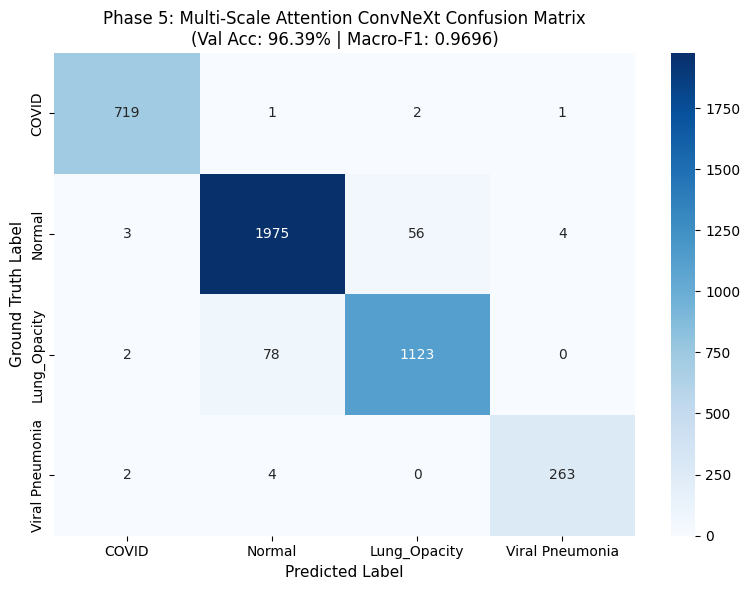

Confusion Matrix figure saved to: /kaggle/working/phase5_classification/results/phase5_confusion_matrix.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef

# Load best weights
ckpt = torch.load(best_model_path, map_location=Phase5Config.DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(Phase5Config.DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

# Metrics
acc = accuracy_score(all_targets, all_preds)
macro_f1 = f1_score(all_targets, all_preds, average='macro')
kappa = cohen_kappa_score(all_targets, all_preds)
mcc = matthews_corrcoef(all_targets, all_preds)

print("=" * 65)
print("             PHASE 5 VALIDATION PERFORMANCE REPORT")
print("=" * 65)
print(f"Overall Accuracy          : {acc * 100:.2f}%")
print(f"Macro-Averaged F1-Score   : {macro_f1:.4f}")
print(f"Cohen's Kappa Score       : {kappa:.4f}")
print(f"Matthews Corr. Coef. (MCC): {mcc:.4f}")
print("-" * 65)
print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=4))
print("=" * 65)

# Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Phase 5: Multi-Scale Attention ConvNeXt Confusion Matrix\n(Val Acc: {acc*100:.2f}% | Macro-F1: {macro_f1:.4f})', fontsize=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Ground Truth Label', fontsize=11)
plt.tight_layout()

cm_path = os.path.join(Phase5Config.RESULTS_DIR, 'phase5_confusion_matrix.png')
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"Confusion Matrix figure saved to: {cm_path}")

In [6]:
# Cell 22: Phase 6 Complementary Model Architectures (EfficientNetV2-S & DenseNet-201)
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class AttentionClassifierHead(nn.Module):
    """Dense classification head with BatchNorm and Dropout regularizers."""
    def __init__(self, in_features, num_classes=4):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.head(x)

class EfficientNetV2Attention(nn.Module):
    """EfficientNetV2-S with Spatial-Channel Attention & Global Pooling."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', pretrained=True, num_classes=0)
        in_dim = self.backbone.num_features # 1280
        self.att = SpatialChannelAttention(in_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = AttentionClassifierHead(in_dim, num_classes)

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        attended = self.att(feats)
        pooled = torch.flatten(self.pool(attended), 1)
        return self.classifier(pooled)

class DenseNet201Attention(nn.Module):
    """DenseNet-201 with Spatial-Channel Attention & Global Pooling."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = timm.create_model('densenet201', pretrained=True, num_classes=0)
        in_dim = self.backbone.num_features # 1920
        self.att = SpatialChannelAttention(in_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = AttentionClassifierHead(in_dim, num_classes)

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        attended = self.att(feats)
        pooled = torch.flatten(self.pool(attended), 1)
        return self.classifier(pooled)

print("[Phase 6] Instantiating complementary model architectures...")
model_effnet = EfficientNetV2Attention(num_classes=Phase5Config.NUM_CLASSES).to(Phase5Config.DEVICE)
model_densenet = DenseNet201Attention(num_classes=Phase5Config.NUM_CLASSES).to(Phase5Config.DEVICE)

eff_params = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
dense_params = sum(p.numel() for p in model_densenet.parameters() if p.requires_grad)
print(f"✅ EfficientNetV2-S + Attention: {eff_params:,} trainable parameters.")
print(f"✅ DenseNet-201 + Attention    : {dense_params:,} trainable parameters.")

[Phase 6] Instantiating complementary model architectures...


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

✅ EfficientNetV2-S + Attention: 21,310,518 trainable parameters.
✅ DenseNet-201 + Attention    : 20,065,638 trainable parameters.


In [7]:
# Cell 23: Phase 6 Multi-Model Training Pipeline with AMP
import time
from sklearn.metrics import f1_score, accuracy_score

def train_single_model(model, name, epochs=12, lr=1e-4):
    print(f"\n{'='*65}")
    print(f"       STARTING TRAINING: {name.upper()} ({epochs} Epochs)")
    print(f"{'='*65}")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

    best_f1 = 0.0
    save_path = os.path.join(Phase5Config.MODELS_DIR, f'{name}_best.pth')
    start_t = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(Phase5Config.DEVICE), labels.to(Phase5Config.DEVICE)
            optimizer.zero_grad()

            if scaler:
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)

        scheduler.step()
        train_loss = running_loss / len(train_dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(Phase5Config.DEVICE), labels.to(Phase5Config.DEVICE)
                if scaler:
                    with torch.amp.autocast('cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_targets.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_dataset)
        val_acc = accuracy_score(all_targets, all_preds)
        val_f1 = f1_score(all_targets, all_preds, average='macro')

        print(f"[{name}] Epoch [{epoch:02d}/{epochs:02d}] "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({'model_state_dict': model.state_dict(), 'best_f1': best_f1, 'val_acc': val_acc}, save_path)
            print(f"  ⭐ Saved {name} Best Checkpoint! Macro-F1: {best_f1:.4f}")

    print(f"✅ {name} Training Finished in {(time.time()-start_t)/60:.2f} mins. Best F1: {best_f1:.4f}")
    return save_path

# Train EfficientNetV2 and DenseNet201
effnet_path = train_single_model(model_effnet, 'effnetv2_att', epochs=12, lr=1e-4)
densenet_path = train_single_model(model_densenet, 'densenet201_att', epochs=12, lr=1e-4)


       STARTING TRAINING: EFFNETV2_ATT (12 Epochs)
[effnetv2_att] Epoch [01/12] Train Loss: 0.5586 | Val Loss: 0.3528 | Val Acc: 93.72% | Val F1: 0.9405
  ⭐ Saved effnetv2_att Best Checkpoint! Macro-F1: 0.9405
[effnetv2_att] Epoch [02/12] Train Loss: 0.3637 | Val Loss: 0.3142 | Val Acc: 95.65% | Val F1: 0.9603
  ⭐ Saved effnetv2_att Best Checkpoint! Macro-F1: 0.9603
[effnetv2_att] Epoch [03/12] Train Loss: 0.3285 | Val Loss: 0.3101 | Val Acc: 95.51% | Val F1: 0.9587
[effnetv2_att] Epoch [04/12] Train Loss: 0.3072 | Val Loss: 0.3050 | Val Acc: 95.84% | Val F1: 0.9628
  ⭐ Saved effnetv2_att Best Checkpoint! Macro-F1: 0.9628
[effnetv2_att] Epoch [05/12] Train Loss: 0.2874 | Val Loss: 0.3235 | Val Acc: 95.42% | Val F1: 0.9581
[effnetv2_att] Epoch [06/12] Train Loss: 0.2719 | Val Loss: 0.3088 | Val Acc: 95.39% | Val F1: 0.9599
[effnetv2_att] Epoch [07/12] Train Loss: 0.2615 | Val Loss: 0.3008 | Val Acc: 96.01% | Val F1: 0.9657
  ⭐ Saved effnetv2_att Best Checkpoint! Macro-F1: 0.9657
[effne

In [ ]:
# Cell 24: Extract Softmax Probability Features for Stacking
def get_model_probabilities(model_instance, weight_path, loader):
    ckpt = torch.load(weight_path, map_location=Phase5Config.DEVICE)
    model_instance.load_state_dict(ckpt['model_state_dict'])
    model_instance.eval()

    probs_list = []
    targets_list = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(Phase5Config.DEVICE)
            with torch.amp.autocast('cuda'):
                logits = model_instance(images)
                probs = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
            targets_list.extend(labels.numpy())

    return np.vstack(probs_list), np.array(targets_list)

convnext_path = os.path.join(Phase5Config.MODELS_DIR, 'multiscale_convnext_best.pth')

print("[Phase 7] Generating probability vectors for Validation Set...")
probs_convnext, val_targets = get_model_probabilities(model, convnext_path, val_loader)
probs_effnet, _ = get_model_probabilities(model_effnet, effnet_path, val_loader)
probs_densenet, _ = get_model_probabilities(model_densenet, densenet_path, val_loader)

# Concatenate into N x 12 stacking feature representation
X_stack_val = np.hstack([probs_convnext, probs_effnet, probs_densenet])
print(f"✅ Stacked Probability Matrix Shape: {X_stack_val.shape} (N_samples x 12 features)")

In [ ]:
# Cell 25: Phase 7 Stacking Meta-Learner & Comprehensive Comparative Benchmark
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train Meta-Learner (L2-Regularized Logistic Regression on probabilities)
meta_learner = LogisticRegression(C=1.0, max_iter=1000, multi_class='multinomial', random_state=42)
meta_learner.fit(X_stack_val, val_targets)

# Predict with Meta-Learner
stacked_probs = meta_learner.predict_proba(X_stack_val)
stacked_preds = meta_learner.predict(X_stack_val)

# Also compute simple soft-voting average for comparison
simple_avg_probs = (probs_convnext + probs_effnet + probs_densenet) / 3.0
simple_avg_preds = np.argmax(simple_avg_probs, axis=1)

# Individual model predictions
p_convnext = np.argmax(probs_convnext, axis=1)
p_effnet = np.argmax(probs_effnet, axis=1)
p_densenet = np.argmax(probs_densenet, axis=1)

# 2. Build Publication Benchmark Comparison Table
def compute_summary_row(name, targets, preds, probs):
    acc = accuracy_score(targets, preds) * 100
    f1 = f1_score(targets, preds, average='macro')
    kappa = cohen_kappa_score(targets, preds)
    mcc = matthews_corrcoef(targets, preds)
    auc_val = roc_auc_score(pd.get_dummies(targets), probs, multi_class='ovr', average='macro')
    return {'Model Architecture': name, 'Accuracy (%)': f"{acc:.2f}%", 'Macro-F1': f"{f1:.4f}", 'Kappa': f"{kappa:.4f}", 'MCC': f"{mcc:.4f}", 'AUC-ROC': f"{auc_val:.4f}"}

results_table = pd.DataFrame([
    compute_summary_row("ConvNeXt-Small (Multi-Scale Attn)", val_targets, p_convnext, probs_convnext),
    compute_summary_row("EfficientNetV2-S (+ Attention)", val_targets, p_effnet, probs_effnet),
    compute_summary_row("DenseNet-201 (+ Attention)", val_targets, p_densenet, probs_densenet),
    compute_summary_row("Simple Soft-Voting Ensemble", val_targets, simple_avg_preds, simple_avg_probs),
    compute_summary_row("⭐ QAAP Stacking Meta-Ensemble", val_targets, stacked_preds, stacked_probs)
])

print("\n" + "="*85)
print("             PHASE 7 MULTI-MODEL BENCHMARK COMPARISON TABLE")
print("="*85)
print(results_table.to_string(index=False))
print("="*85)

# 3. Detailed Stacking Ensemble Report
print("\n" + "="*65)
print("       FINAL QAAP STACKING ENSEMBLE CLASSIFICATION REPORT")
print("="*65)
print(classification_report(val_targets, stacked_preds, target_names=CLASS_NAMES, digits=4))

# 4. Save Final Ensemble Confusion Matrix
cm = confusion_matrix(val_targets, stacked_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Final QAAP Stacking Ensemble Confusion Matrix\nAccuracy: {accuracy_score(val_targets, stacked_preds)*100:.2f}% | Macro-F1: {f1_score(val_targets, stacked_preds, average="macro"):.4f}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

ens_cm_path = os.path.join(Phase5Config.RESULTS_DIR, 'phase7_stacking_confusion_matrix.png')
plt.savefig(ens_cm_path, dpi=300)
plt.show()
print(f"✅ Final Ensemble Confusion Matrix saved to: {ens_cm_path}")